# 0. Librerías y generalización de rutas

In [11]:
from pathlib import Path
from datetime import datetime, timedelta
import re, warnings, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
import seaborn as sns
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW, PROC, FIG = ROOT / "data" / "raw", ROOT / "data" / "processed", ROOT / "reports" / "figuras"
for p in (RAW, PROC, FIG):
    p.mkdir(parents=True, exist_ok=True)

# Zonas con las que se entrena (texto que debe aparecer en la columna Línea). None = todas.
ZONAS = ["AutoNorte", "Calle 26", "NQS Sur"]

# Estaciones de estudio: código -> nombre corto. Los resultados se reportan para estas.
ESTUDIO = {"02200": "Alcalá", "06001": "Modelia", "07504": "Terreros"}

# Festivos del periodo (confirmar con un calendario oficial)
FESTIVOS = pd.to_datetime(["2026-06-08", "2026-06-15", "2026-06-29", "2026-07-13",
                           "2026-07-20", "2026-08-07", "2026-08-17"])

URL_GTFS = "https://storage.googleapis.com/gtfs-estaticos/GTFS_20260712.zip"
DIAS_TEST = 21        # los últimos días del periodo se reservan como conjunto de prueba
N_FOLDS = 5           # validación cruzada por grupos de fecha
RECARGAR = False      # True = volver a leer los Excel aunque exista el archivo procesado

In [12]:
# Estilo común de las gráficas
from cycler import cycler
from matplotlib.colors import LinearSegmentedColormap

AZUL, NARANJA, VERDE, GRIS, TINTA = "#2a78d6", "#eb6834", "#1baf7a", "#b9b8b2", "#52514e"
COLOR_DIA = {"habil": AZUL, "sabado": NARANJA, "domingo_festivo": VERDE}
NOMBRE_DIA = {"habil": "Día hábil", "sabado": "Sábado", "domingo_festivo": "Domingo o festivo"}
COLOR_EST = dict(zip(ESTUDIO.values(), [AZUL, NARANJA, VERDE]))
DIAS = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
MAPA_AZUL = LinearSegmentedColormap.from_list("azul", ["#fcfcfb", "#cde2fb", "#6da7ec", "#2a78d6", "#0d366b"])
MAPA_DIVERGENTE = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": GRIS,
    "axes.grid": True, "grid.color": "#e7e6e2", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "lines.linewidth": 2, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": TINTA, "xtick.color": TINTA, "ytick.color": TINTA, "legend.frameon": False,
    "axes.prop_cycle": cycler(color=[AZUL, NARANJA, VERDE, "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"])})

def eje_horas(ax):
    ax.set_xticks(range(4, 24, 4)); ax.set_xticklabels([f"{h:02d}:00" for h in range(4, 24, 4)])
    ax.set_xlabel("Hora del día")

def miles(x, _=None):
    return f"{x / 1000:,.0f} mil".replace(",", ".") if abs(x) >= 1000 else f"{x:,.0f}"

# 1. Carga de Datos


In [17]:
import pandas as pd

# 1. Leer el Excel
df = pd.read_excel(RAW/"Validaciones_Agosto.xlsx")

# 2. Eliminar las filas donde Fase = "Dual"
df = df[df["Fase"] != "Dual"].copy()

# 3. Identificar las columnas de fechas usando iloc
#    Las fechas están desde la columna 6 hasta la 36
columnas_fecha = df.columns[5:36]

# 4. Pasar de formato ancho a formato largo
#
#    Cada registro original se convierte en 31 registros:
#    uno por cada día de agosto.
data = df.melt(
    id_vars=["Línea", "Estación", "Intervalo"],
    value_vars=columnas_fecha,
    var_name="Fecha",
    value_name="Validaciones"
)

# 5. Convertir Fecha a datetime
data["Fecha"] = pd.to_datetime(data["Fecha"])

# 6. Sumar las validaciones agrupando por:
#    Línea, Estación, Intervalo y Fecha
data = (
    data
    .groupby(
        ["Línea", "Estación", "Intervalo", "Fecha"],
        as_index=False
    )["Validaciones"]
    .sum()
)

# 7. Ordenar el resultado
data = data.sort_values(
    ["Línea", "Estación", "Fecha", "Intervalo"]
).reset_index(drop=True)

# 8. Verificar resultado
print(data.head())
print(data.shape)
print(data.columns)
from datetime import time
data[
    (data['Estación']=='(07504) TERREROS') &
    (data['Intervalo'] == time(4,15))
]

                  Línea         Estación Intervalo      Fecha  Validaciones
0  (11) Zona K Calle 26  (06001) Modelia  04:15:00 2026-08-01             0
1  (11) Zona K Calle 26  (06001) Modelia  04:30:00 2026-08-01             0
2  (11) Zona K Calle 26  (06001) Modelia  04:45:00 2026-08-01             3
3  (11) Zona K Calle 26  (06001) Modelia  05:00:00 2026-08-01             6
4  (11) Zona K Calle 26  (06001) Modelia  05:15:00 2026-08-01            12
(294004, 5)
Index(['Línea', 'Estación', 'Intervalo', 'Fecha', 'Validaciones'], dtype='object')


,Línea,Estación,Intervalo,Fecha,Validaciones
69163,(30) Zona G NQS Sur,(07504) TERREROS,04:15:00,2026-08-01,204
69241,(30) Zona G NQS Sur,(07504) TERREROS,04:15:00,2026-08-02,57
69319,(30) Zona G NQS Sur,(07504) TERREROS,04:15:00,2026-08-03,353
69397,(30) Zona G NQS Sur,(07504) TERREROS,04:15:00,2026-08-04,341
69475,(30) Zona G NQS Sur,(07504) TERREROS,04:15:00,2026-08-05,300
69553,(30) Zona G NQS Sur,(07504) TERREROS,04:15:00,2026-08-06,325
69631,(30) Zona G NQS Sur,(07504) TERREROS,04:15:00,2026-08-07,100
69709,(30) Zona G NQS Sur,(07504) TERREROS,04:15:00,2026-08-08,174
69787,(30) Zona G NQS Sur,(07504) TERREROS,04:15:00,2026-08-09,77
69865,(30) Zona G NQS Sur,(07504) TERREROS,04:15:00,2026-08-10,366


In [18]:
import numpy as np

data = data.rename(columns={"Línea": "linea", "Estación": "estación", "Intervalo": "intervalo",
                            "Fecha": "fecha", "Validaciones": "validaciones"})

FESTIVOS = pd.to_datetime(["2026-08-07", "2026-08-17"])        # festivos de agosto de 2026
dia = data["fecha"].dt.dayofweek
data["tipo_dia"] = np.select([data["fecha"].isin(FESTIVOS) | (dia == 6), dia == 5],
                             ["domingo_festivo", "sabado"], "habil")

print(data.shape, "| Estaciones:", data["estación"].nunique())
print(data.groupby("tipo_dia")["fecha"].nunique())

(294004, 6) | Estaciones: 123
tipo_dia
domingo_festivo     7
habil              19
sabado              5
Name: fecha, dtype: int64


## 2. Modelos Utilizados

### 2.1 Partición en entrenamiento y prueba

Se separa el 20 % de los registros para la prueba final, estratificando por estación: cada estación
queda con el mismo porcentaje de sus datos en entrenamiento y en prueba. Los datos de prueba no se
usan para ajustar ni para escoger modelos; solo para la comparación final de la sección 4.

In [28]:
X = data[["linea", "estación", "intervalo", "fecha", "tipo_dia"]]
y = data["validaciones"]

en_test = data["fecha"].dt.day >= 26          # 26 al 31 de agosto -> prueba; 1 al 25 -> entrenamiento
X_train, X_test = X[~en_test], X[en_test]
y_train, y_test = y[~en_test], y[en_test]

print("Train:", X_train.shape, "| del", X_train["fecha"].min().date(), "al", X_train["fecha"].max().date())
print("Test: ", X_test.shape, "| del", X_test["fecha"].min().date(), "al", X_test["fecha"].max().date())
pct = X_test["estación"].value_counts() / data["estación"].value_counts() * 100
print(f"Estaciones en test: {X_test['estación'].nunique()} de {data['estación'].nunique()}"
      f" | % de cada estación en test: de {pct.min():.1f} a {pct.max():.1f}")
print(X_test.groupby("tipo_dia")["fecha"].nunique())

Train: (237100, 5) | del 2026-08-01 al 2026-08-25
Test:  (56904, 5) | del 2026-08-26 al 2026-08-31
Estaciones en test: 123 de 123 | % de cada estación en test: de 19.4 a 19.4
tipo_dia
domingo_festivo    1
habil              4
sabado             1
Name: fecha, dtype: int64


### 2.2 Preparación de las variables

- **Variable a predecir:** validaciones en la franja de 15 minutos.
- **Categóricas** (`linea`, `estación`, `tipo_dia`): codificación one-hot.
- **Hora:** el intervalo convertido a número (05:15 → 5,25) y estandarizado, como exigen Ridge, Lasso y los kernels.
- **Fecha:** no entra directamente; su información está en `tipo_dia`.

La preparación va dentro de un *pipeline*, de modo que en cada pliegue se ajusta solo con los datos
de entrenamiento de ese pliegue (sin fuga de información).

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_approximation import Nystroem
from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def a_hora(v):                       # "05:15" -> 5.25
    h, m = str(v).split(":")[:2]
    return int(h[-2:]) + int(m) / 60

def agregar(d):
    d = d.copy()
    d["hora"] = d["intervalo"].map(a_hora)
    d["est_franja"] = d["estación"] + " | " + d["intervalo"].astype(str)     # cada estación con su propia curva
    d["dia_franja"] = d["tipo_dia"] + " | " + d["intervalo"].astype(str)     # la curva cambia según el tipo de día
    d["est_dia"] = d["estación"] + " | " + d["tipo_dia"]                     # cada estación cae distinto el fin de semana
    return d

X_train, X_test = agregar(X_train), agregar(X_test)

CATEGORICAS = ["linea", "estación", "tipo_dia", "est_franja", "dia_franja", "est_dia"]
NUMERICAS = ["hora"]

def preparar():
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAS),
                              ("num", StandardScaler(), NUMERICAS)])

con_splines = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAS),
                                 ("spl", SplineTransformer(), NUMERICAS)])

cv = KFold(n_splits=5, shuffle=True, random_state=42)     # los mismos 5 pliegues para todos los modelos

### 2.3 Los seis modelos con sus parámetros por defecto

Primera comparación: cada método tal como viene, con validación cruzada de 5 pliegues **sobre
entrenamiento**. La línea base predice siempre la media y es el piso que todos deben superar.

| Modelo | Qué hace con estos datos |
|---|---|
| Base (media) | Predice el promedio de validaciones para todo |
| OLS | Un efecto por línea, estación y tipo de día, y una recta para la hora |
| Ridge | Igual que OLS, encogiendo los coeficientes |
| Lasso | Igual que OLS, pudiendo llevar coeficientes a cero |
| Splines | Reemplaza la recta de la hora por una curva suave |
| Kernel (RBF) | Parecido entre registros; aproximado con Nyström porque el kernel exacto no cabe en memoria |

In [33]:
modelos = {"Base (media)": make_pipeline(preparar(), DummyRegressor(strategy="mean")),
           "OLS":          make_pipeline(preparar(), LinearRegression()),
           "Ridge":        make_pipeline(preparar(), Ridge(alpha=1.0)),
           "Lasso":        make_pipeline(preparar(), Lasso(alpha=1.0)),
           "Splines":      make_pipeline(con_splines, LinearRegression()),
           "Kernel (RBF)": make_pipeline(preparar(), Nystroem(kernel="rbf", gamma=None, n_components=100,
                                                              random_state=2026), Ridge(alpha=1.0))}
filas = {}
for nombre, m in modelos.items():
    r = cross_validate(m, X_train, y_train, cv=cv, n_jobs=-1,
                       scoring=("neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"))
    filas[nombre] = {"MAE": -r["test_neg_mean_absolute_error"].mean(),
                     "RMSE": -r["test_neg_root_mean_squared_error"].mean(),
                     "RMSE (desv. entre pliegues)": r["test_neg_root_mean_squared_error"].std(),
                     "R2": r["test_r2"].mean()}
tabla_cv = pd.DataFrame(filas).T.sort_values("RMSE")
display(tabla_cv.round(3))

,MAE,RMSE,RMSE (desv. entre pliegues),R2
Ridge,41.806,86.853,1.029,0.839
OLS,41.331,86.867,1.096,0.839
Splines,41.331,86.867,1.096,0.839
Lasso,85.101,181.106,2.393,0.298
Kernel (RBF),94.517,200.972,3.142,0.136
Base (media),104.648,216.219,2.379,-0.000


### 2.3 Búsqueda en grilla de los tres finalistas

Los tres modelos de menor RMSE en la tabla anterior pasan a búsqueda en grilla, con los mismos
pliegues y solo con datos de entrenamiento. Si un valor ganador queda en el borde de su grilla,
la celda lo avisa y la grilla se amplía hacia ese lado.

In [34]:
GRILLAS = {"OLS":          {},
           "Ridge":        {"ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000]},
           "Lasso":        {"lasso__alpha": [0.001, 0.01, 0.1, 1, 10]},
           "Splines":      {"columntransformer__spl__n_knots": [5, 10, 20, 40, 60, 80]},
           "Kernel (RBF)": {"nystroem__gamma": [0.03, 0.1, 0.3, 1],
                            "nystroem__n_components": [200],
                            "ridge__alpha": [0.001, 0.01, 0.1, 1, 10]}}

finalistas = tabla_cv.drop(index="Base (media)").index[:3].tolist()
print("Finalistas (los tres de menor RMSE en validación cruzada):", finalistas)

ajustados, filas = {}, {}
for nombre in finalistas:
    b = GridSearchCV(modelos[nombre], GRILLAS[nombre], cv=cv, n_jobs=-1,
                     scoring="neg_root_mean_squared_error").fit(X_train, y_train)
    ajustados[nombre] = b.best_estimator_
    filas[nombre] = {"RMSE en CV (por defecto)": tabla_cv.loc[nombre, "RMSE"],
                     "RMSE en CV (ajustado)": -b.best_score_,
                     "Hiperparámetros": ", ".join(f"{k.split('__')[-1]} = {v}" for k, v in b.best_params_.items()) or "no tiene"}
    for k, v in b.best_params_.items():
        if len(GRILLAS[nombre][k]) > 1 and v in (GRILLAS[nombre][k][0], GRILLAS[nombre][k][-1]):
            print(f"   OJO {nombre}: {k.split('__')[-1]} = {v} quedó en el borde de la grilla")

comparacion = pd.DataFrame(filas).T.sort_values("RMSE en CV (ajustado)")
display(comparacion)
mejor = comparacion.index[0]
print("Mejor por validación cruzada:", mejor)

Finalistas (los tres de menor RMSE en validación cruzada): ['Ridge', 'OLS', 'Splines']


,RMSE en CV (por defecto),RMSE en CV (ajustado),Hiperparámetros
Ridge,86.853098,86.841315,alpha = 0.1
Splines,86.866898,86.86677,n_knots = 20
OLS,86.86685,86.86685,no tiene


Mejor por validación cruzada: Ridge


### 3.4 Matriz de aplicabilidad

| Método | ¿Aporta? | RMSE en CV | Justificación |
|---|---|---|---|
| Base (media) | Referencia | ___ | Piso de comparación |
| OLS | ___ | ___ | ___ |
| Ridge | ___ | ___ | ___ |
| Lasso | ___ | ___ | ___ |
| Splines | ___ | ___ | ___ |
| Kernel (RBF) | ___ | ___ | ___ |

**Finalistas:** ___, ___ y ___. **Hiperparámetros escogidos:** ___.

## 3. Comparación final en los datos de prueba

### 3.1 Error de los finalistas en prueba

Es la primera y única vez que se usan los datos de prueba. Los errores están en validaciones por
franja de 15 minutos.

In [36]:
en_prueba = {"Base (media)": modelos["Base (media)"].fit(X_train, y_train), **{n: ajustados[n] for n in comparacion.index}}
pred = {nombre: m.predict(X_test) for nombre, m in en_prueba.items()}

tabla_test = pd.DataFrame({nombre: {"MAE": mean_absolute_error(y_test, p),
                                    "RMSE": root_mean_squared_error(y_test, p),
                                    "R2": r2_score(y_test, p)} for nombre, p in pred.items()}).T
tabla_test["Mejora en MAE frente a la base"] = (1 - tabla_test["MAE"] / tabla_test.loc["Base (media)", "MAE"]).map("{:.0%}".format)
display(tabla_test.round(3))

,MAE,RMSE,R2,Mejora en MAE frente a la base
Base (media),105.140,220.670,-0.001,0%
Ridge,38.802,80.396,0.867,63%
Splines,38.729,80.347,0.867,63%
OLS,38.729,80.347,0.867,63%


### 3.2 Bootstrap: ¿la diferencia entre finalistas es real?

Se remuestrean 1.000 veces los días de los datos de prueba (días completos, porque las franjas de un
mismo día se parecen entre sí) y se recalcula el error de cada modelo. Si el intervalo del 95 % de la
diferencia frente al mejor no incluye el 0, la ventaja es real.

In [37]:
B = 1000
rng = np.random.default_rng(42)
dia = pd.to_datetime(X_test["fecha"]).dt.date.to_numpy()
dias = np.unique(dia)
muestras = rng.integers(0, len(dias), size=(B, len(dias)))          # los mismos días para todos los modelos

def por_dia(valores):                                               # suma de cada día, en el orden de `dias`
    return pd.Series(valores).groupby(dia).sum().reindex(dias).to_numpy()

n = por_dia(np.ones(len(X_test)))
boot = {}
for nombre in comparacion.index:                                    # del mejor al peor por CV
    e = y_test.to_numpy() - pred[nombre]
    abs_dia, cuad_dia = por_dia(np.abs(e)), por_dia(e ** 2)
    boot[nombre] = {"MAE": abs_dia[muestras].sum(1) / n[muestras].sum(1),
                    "RMSE": np.sqrt(cuad_dia[muestras].sum(1) / n[muestras].sum(1))}

def intervalo(v):
    return f"{v.mean():.2f}  [{np.percentile(v, 2.5):.2f}, {np.percentile(v, 97.5):.2f}]"

display(pd.DataFrame({k: {met: intervalo(v) for met, v in d.items()} for k, d in boot.items()}).T
        .rename(columns=lambda c: c + " en prueba, IC 95 %"))

for otro in comparacion.index[1:]:
    for met in ("MAE", "RMSE"):
        dif = boot[otro][met] - boot[mejor][met]
        lo, hi = np.percentile(dif, [2.5, 97.5])
        print(f"{met}: {otro} − {mejor} = {dif.mean():.2f}  [{lo:.2f}, {hi:.2f}]  ->",
              "diferencia real" if lo > 0 or hi < 0 else "no se distinguen (el intervalo incluye 0)")

,"MAE en prueba, IC 95 %","RMSE en prueba, IC 95 %"
Ridge,"38.75 [34.23, 46.81]","79.80 [67.06, 98.26]"
Splines,"38.67 [34.12, 46.83]","79.74 [67.03, 98.43]"
OLS,"38.67 [34.12, 46.83]","79.74 [67.03, 98.43]"


MAE: Splines − Ridge = -0.08  [-0.22, 0.11]  -> no se distinguen (el intervalo incluye 0)
RMSE: Splines − Ridge = -0.07  [-0.37, 0.29]  -> no se distinguen (el intervalo incluye 0)
MAE: OLS − Ridge = -0.08  [-0.22, 0.11]  -> no se distinguen (el intervalo incluye 0)
RMSE: OLS − Ridge = -0.07  [-0.37, 0.29]  -> no se distinguen (el intervalo incluye 0)


### 3.3 Comportamiento en Alcalá, Modelia y Terreros

El mejor modelo frente a los datos reales en un lunes hábil de agosto escogido al azar. La línea es
la predicción; los puntos negros son datos de prueba y los grises son datos de entrenamiento de ese
mismo día. La tabla resume el error de cada estación en todos sus datos de prueba.

Lunes de entrenamiento: 2026-08-24 | Lunes de prueba: 2026-08-31


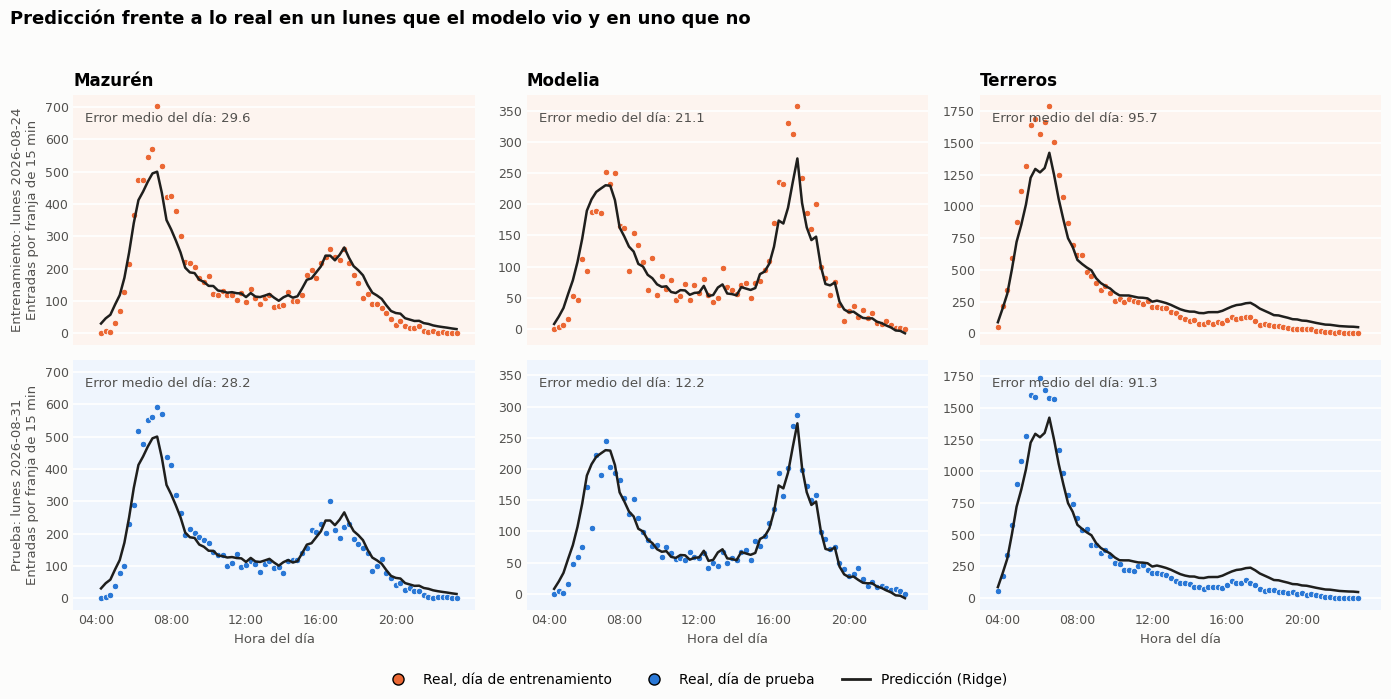

Modelo: Ridge | Error por estación, entrenamiento (1 al 25) contra prueba (26 al 31):


,Entradas promedio (prueba),MAE entrenamiento,MAE prueba,RMSE prueba,MAE prueba / promedio
Mazurén,125.82,31.38,31.15,44.33,0.25
Modelia,71.44,18.45,16.88,24.81,0.24
Terreros,294.04,114.26,106.78,155.66,0.36


In [49]:
import unicodedata
from matplotlib.lines import Line2D

def sin_tilde(s):                                   # "MAZURÉN" -> "mazuren"
    return unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower()

modelo = ajustados[mejor]
ESTUDIO = {"Mazurén": "mazuren", "Modelia": "modelia", "Terreros": "terreros"}     # nombre -> texto a buscar (sin tilde)
est_norm = data["estación"].map(sin_tilde)

# Un lunes hábil de entrenamiento (1 al 25, al azar) y el lunes hábil de prueba (26 al 31)
fechas = pd.to_datetime(data["fecha"])
dias_lunes = pd.to_datetime(data.loc[(fechas.dt.dayofweek == 0) & (data["tipo_dia"] == "habil"), "fecha"]).drop_duplicates()
LUNES_TRAIN = dias_lunes[dias_lunes.dt.day <= 25].sample(1, random_state=2026).iloc[0]
LUNES_TEST = dias_lunes[dias_lunes.dt.day >= 26].iloc[0]
print("Lunes de entrenamiento:", LUNES_TRAIN.date(), "| Lunes de prueba:", LUNES_TEST.date())

NARANJA, AZUL, TINTA = "#eb6834", "#2a78d6", "#1f1f1d"
FILAS = [(LUNES_TRAIN, "Entrenamiento", NARANJA, "#fdf4ef"),
         (LUNES_TEST,  "Prueba",        AZUL,    "#eff5fd")]

fig, ejes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey="col")
for fila, (dia, rol, color, fondo) in enumerate(FILAS):
    for col, (est, buscar) in enumerate(ESTUDIO.items()):
        ax = ejes[fila, col]
        nombre = data.loc[est_norm.str.contains(buscar), "estación"].iloc[0]
        d = data[(data["estación"] == nombre) & (fechas == dia)].copy()
        d = agregar(d).sort_values("hora")
        d["pred"] = modelo.predict(d[X_train.columns])
        mae_dia = mean_absolute_error(d.validaciones, d.pred)

        ax.set_facecolor(fondo)
        ax.grid(axis="y", color="white", linewidth=1.2)
        ax.grid(axis="x", visible=False)
        ax.set_axisbelow(True)
        ax.scatter(d.hora, d.validaciones, s=22, color=color, edgecolor="white", linewidth=0.6, zorder=3)
        ax.plot(d.hora, d.pred, color=TINTA, linewidth=1.8, zorder=4)
        ax.text(0.03, 0.93, f"Error medio del día: {mae_dia:.1f}", transform=ax.transAxes,
                ha="left", va="top", fontsize=9.5, color="#52514e")
        for lado in ("top", "right", "left", "bottom"):
            ax.spines[lado].set_visible(False)
        ax.tick_params(length=0, labelsize=9)
        if fila == 0:
            ax.set_title(est, loc="left", fontweight="bold", fontsize=12)
        if fila == 1:
            ax.set_xticks(range(4, 24, 4)); ax.set_xticklabels([f"{h:02d}:00" for h in range(4, 24, 4)])
            ax.set_xlabel("Hora del día", fontsize=9.5)
    ejes[fila, 0].set_ylabel(f"{rol}: lunes {dia.date()}\nEntradas por franja de 15 min", fontsize=9.5)

leyenda = [Line2D([0], [0], marker="o", color="none", markerfacecolor=NARANJA, markersize=8, label="Real, día de entrenamiento"),
           Line2D([0], [0], marker="o", color="none", markerfacecolor=AZUL, markersize=8, label="Real, día de prueba"),
           Line2D([0], [0], color=TINTA, linewidth=2, label=f"Predicción ({mejor})")]
fig.legend(handles=leyenda, loc="lower center", ncol=3, frameon=False, fontsize=10)
fig.suptitle("Predicción frente a lo real en un lunes que el modelo vio y en uno que no", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0.05, 1, 0.96)); plt.show()

errores = {}
for est, buscar in ESTUDIO.items():                                 # error de cada estación en todos sus datos
    nombre = data.loc[est_norm.str.contains(buscar), "estación"].iloc[0]
    tr, te = X_train[X_train["estación"] == nombre], X_test[X_test["estación"] == nombre]
    errores[est] = {"Entradas promedio (prueba)": y_test[te.index].mean(),
                    "MAE entrenamiento": mean_absolute_error(y_train[tr.index], modelo.predict(tr)),
                    "MAE prueba": mean_absolute_error(y_test[te.index], modelo.predict(te)),
                    "RMSE prueba": root_mean_squared_error(y_test[te.index], modelo.predict(te))}
errores = pd.DataFrame(errores).T
errores["MAE prueba / promedio"] = errores["MAE prueba"] / errores["Entradas promedio (prueba)"]
print("Modelo:", mejor, "| Error por estación, entrenamiento (1 al 25) contra prueba (26 al 31):")
display(errores.round(2))

Sábado de entrenamiento: 2026-08-22 | Sábado de prueba: 2026-08-29


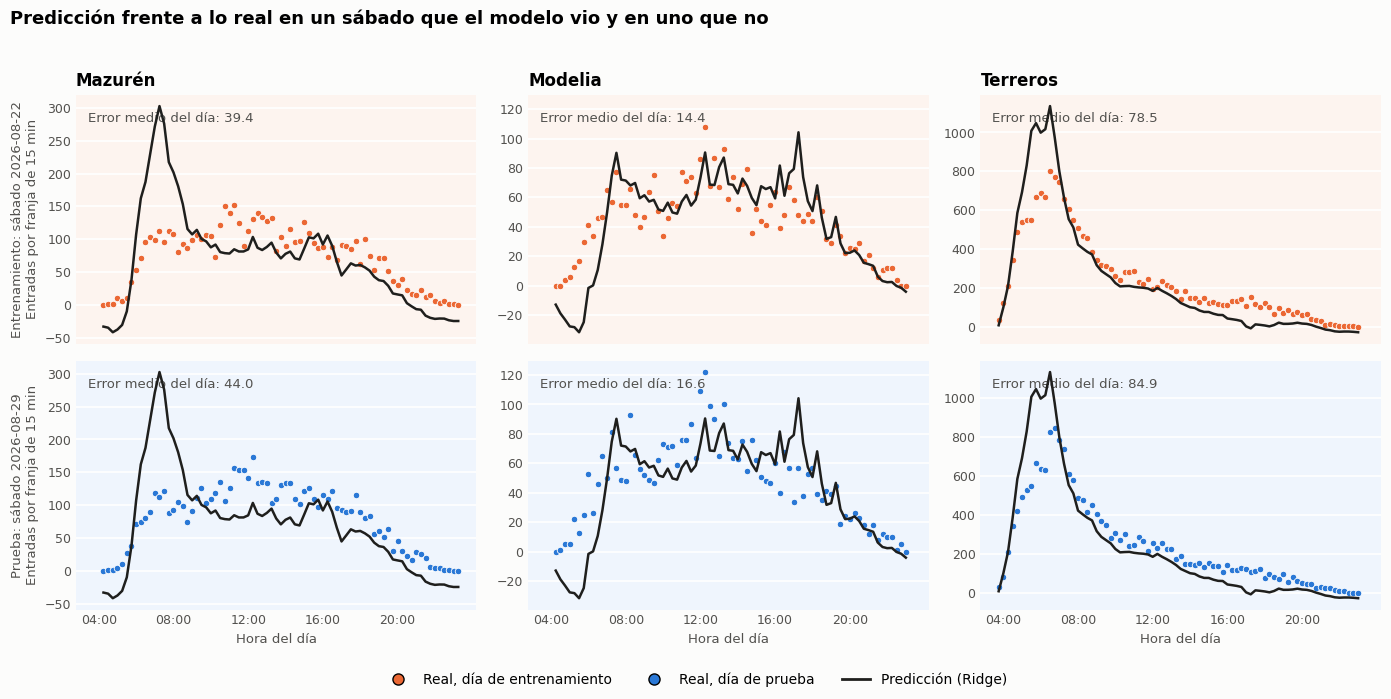

In [50]:
fechas = pd.to_datetime(data["fecha"])
dias_sab = pd.to_datetime(data.loc[(fechas.dt.dayofweek == 5) & (data["tipo_dia"] == "sabado"), "fecha"]).drop_duplicates()
SAB_TRAIN = dias_sab[dias_sab.dt.day <= 25].sample(1, random_state=2026).iloc[0]
SAB_TEST = dias_sab[dias_sab.dt.day >= 26].iloc[0]
print("Sábado de entrenamiento:", SAB_TRAIN.date(), "| Sábado de prueba:", SAB_TEST.date())

FILAS = [(SAB_TRAIN, "Entrenamiento", NARANJA, "#fdf4ef"),
         (SAB_TEST,  "Prueba",        AZUL,    "#eff5fd")]

fig, ejes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey="col")
for fila, (dia, rol, color, fondo) in enumerate(FILAS):
    for col, (est, buscar) in enumerate(ESTUDIO.items()):
        ax = ejes[fila, col]
        nombre = data.loc[est_norm.str.contains(buscar), "estación"].iloc[0]
        d = data[(data["estación"] == nombre) & (fechas == dia)].copy()
        d = agregar(d).sort_values("hora")
        d["pred"] = modelo.predict(d[X_train.columns])
        mae_dia = mean_absolute_error(d.validaciones, d.pred)

        ax.set_facecolor(fondo)
        ax.grid(axis="y", color="white", linewidth=1.2)
        ax.grid(axis="x", visible=False)
        ax.set_axisbelow(True)
        ax.scatter(d.hora, d.validaciones, s=22, color=color, edgecolor="white", linewidth=0.6, zorder=3)
        ax.plot(d.hora, d.pred, color=TINTA, linewidth=1.8, zorder=4)
        ax.text(0.03, 0.93, f"Error medio del día: {mae_dia:.1f}", transform=ax.transAxes,
                ha="left", va="top", fontsize=9.5, color="#52514e")
        for lado in ("top", "right", "left", "bottom"):
            ax.spines[lado].set_visible(False)
        ax.tick_params(length=0, labelsize=9)
        if fila == 0:
            ax.set_title(est, loc="left", fontweight="bold", fontsize=12)
        if fila == 1:
            ax.set_xticks(range(4, 24, 4)); ax.set_xticklabels([f"{h:02d}:00" for h in range(4, 24, 4)])
            ax.set_xlabel("Hora del día", fontsize=9.5)
    ejes[fila, 0].set_ylabel(f"{rol}: sábado {dia.date()}\nEntradas por franja de 15 min", fontsize=9.5)

leyenda = [Line2D([0], [0], marker="o", color="none", markerfacecolor=NARANJA, markersize=8, label="Real, día de entrenamiento"),
           Line2D([0], [0], marker="o", color="none", markerfacecolor=AZUL, markersize=8, label="Real, día de prueba"),
           Line2D([0], [0], color=TINTA, linewidth=2, label=f"Predicción ({mejor})")]
fig.legend(handles=leyenda, loc="lower center", ncol=3, frameon=False, fontsize=10)
fig.suptitle("Predicción frente a lo real en un sábado que el modelo vio y en uno que no", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0.05, 1, 0.96)); plt.show()

### 4.4 Decisión

- **Modelo escogido:** ___, con ___ (hiperparámetros).
- **Error en prueba:** MAE de ___ validaciones por franja (IC 95 %: ___ a ___), ___ % menos que la línea base.
- **Frente a los otros finalistas:** la diferencia con ___ es de ___ [___, ___] y con ___ de ___ [___, ___].
- **Por estación:** Alcalá ___, Modelia ___, Terreros ___ (MAE). Donde más falla es en ___, a las ___.
- **Limitaciones:** un mismo día tiene registros en entrenamiento y en prueba, así que el error mide
  qué tan bien se completan franjas de días ya vistos, no qué tan bien se predice un día nuevo;
  el modelo no usa la oferta de buses ni eventos (marchas, cierres); solo cubre tres troncales.